#**Exploring Machine Learning Approaches for Detecting Parkinson's Disease from speech**

**COMP 490**
<br>Sydney Stoddart, 40193525
<br>Supervisor: Dr. Marta Kersten-Oertel
<br>December 18th, 2025




#**Abstract**

Parkinson's disease (PD) is a neurodegenerative disorder that is associated with early changes in speech. This project explores the use of machine learning models in detecting Parkinson's disease from speech recordings using the PARKCELEB dataset, which contains longitudinal audio data from individuals with PD and control speakers. Both interpretable speech features such as pause-based and intensity-based measures, and non-interpretable acoustic representations extracted from pre-trained models were analyzed.

<br>

Several classification models were evaluated, including logistic regression, linear support vector machines, and random forests. Logistic regression achieved the best overall performance. Feature analysis suggested that pause-related speech characteristics were particularly important, while error analysis indicated that speech samples that were taken many years before diagnosis were more difficult to classify. Overall, this exploratory project demonstrates the potential of speech-based machine learning approaches for Parkinson's disease detection and highlights important directions for further continuation of the project.

<br>

#**Introduction**

**Background**
<br>Parkinson’s disease is a neurodegenerative disorder that causes a progressive loss of motor control, as well as distinct changes in speech articulation. This can lead to a slower speech rate and increased pauses between words (U.S. Department of Health and Human Services). Because changes in speech are some of the first signs of Parkinson’s disease, speech analysis using machine learning approaches presents a promising tool for early detection and monitoring.

<br>

**Project Overview**
<br>This project explores machine learning approaches to detect PD using voice recordings from the PARKCELEB dataset, which was collected in the paper “*Unveiling early signs of Parkinson’s disease via a longitudinal analysis of celebrity speech recordings*”. This dataset contains audio recordings from public figures who were diagnosed with Parkinson’s disease, as well as control individuals who do not have the condition. Each of the recordings includes annotation data such as speaker ID, number of years before diagnosis, and other general information about the speaker, which can be used to analyze model performance.

<br>

**Purpose**
<br>The purpose of this mini-project is to extract and analyze various speech features and to build and evaluate several machine learning models in order to determine their capability in detecting Parkinson’s disease. Both interpretable and non-interpretable features will be examined to explore their predictive importance and to assess how different feature representations contribute to classification performance. This project serves as an exploratory foundation for a larger master’s research project that is being conducted by Nadine El-Mufti, who will compare these methods and results against her own dataset and fine-tuned models.

<br>

**Main Results**
<br>The results of this project demonstrated that speech-based machine learning models can in fact distinguish between Parkinson's disease and control samples, with logistic regression achieving the best overall performance. Exploratory feature analysis suggested that pause-related features were particularly informative, which is consistent with prior research. Error analysis further indicated that speech samples collected many years before clinical diagnosis are more challenging to classify, thus highlighting the importance of temporal context in speech-based Parkinson's disease detection.

#**Methodology**

**Preprocessing**
<br>Data  preprocessing was the largest and most important step for this project, since the audio files used required extensive transformation before they could be used for machine learning analysis. The raw speech recordings along with the speaker-level metadata were acquired from the PARKCELEB dataset. Feature extraction was done using the preprocessing pipeline, which was also acquired from the PARKCELEB repository along with additional custom scripts that were developed for this project. Two categories of features were considered: interpretable and non-interpretable features.

<br>

Interpretable features consisted of pause-based and intensity-based features, which are measures that have a physiological interpretation (Favaro et al., 2024). These included mainly statistics such as mean pause length, pause variability across voice activity detection (VAD) intervals, and pitch variability. The extraction of these features relied on the scripts adapted directly from the PARKCELEB preprocessing pipeline.

<br>

Non-interpretable features were extracted using pretrained acoustic models that produce higher-dimensional representations of speech. These features included x-vectors, TRILLsson, Wav2Vec 2.0, HuBERT, and Whisper, and were processed separately from the interpretable features. These representations capture more complex patterns that are not easily interpretable at the physiological level.

<br>

Following interpretable and non-interpretable feature extraction, all feature files were merged into a single dataset using custom Python scripts. Each feature row was aligned with its corresponding speaker metadata by using unique identifiers that included speaker ID, video ID, and disease status. Supplementary metadata fields, including years_from_diagnosis and before_after_diagnosis were also preserved to allow for error analysis later on.

<br>

---
<br>

**Model Aspects**
<br>Several basic machine learning models were trained using the processed feature sets to classify the samples as either Parkinson's disease (PD) or control (CN). Logistic regression was selected as the main classification model since the extracted features were all numeric and the model is well-suited for high-dimensional feature spaces (Hastie et al., 2017).

<br>

Separate models were trained as well, using only interpretable features and non-interpretable features in order to compare their predictive capabilities and to assess the contribution of each feature type. Additional baseline models, including linear support vector machines (SVM) and random forest classifiers, were trained to compare the performance across different modeling approaches.

<br>

Balanced accuracy was used as the main evaluation metric due to the class imbalance present within the dataset. This metric is more appropriate than raw accuracy for imbalanced classfication tasks, as it accounts for both sensitivity and specificity. The model hyperparameters were initially set to the default values, with additional hyperparameter tuning done.

<br>

In order to assess the relevance of features, permutation feature importance was done for interpretable features using the trained logistic regression model. This approach measures the decrease in model performance when individual features are randomly permuted, which provides insight into which features contribute the most to classification performance. (Fisher et al., 2019)

<br>

Lastly, speaker-level error analysis was conducted by integrating model predictions using speaker metadata. This allowed the Parkinson's disease cases to be analyzed as true positives or false negatives relative to the number of years from diagnosis. This analysis made it possible to examine how the number of years before diagnosis affects the model's performance.

<br>

#**Experimental Setup**

**Dataset**
<br>
The PARKCELEB dataset was used for all experiments in this project. This dataset consists of longitudinal speech recordings from both Parkinson's disease (PD) speakers and control speakers (CN), along with detailed metadata that includes speaker identity and years relative to clinical diagnosis. For this project, a subset of the dataset was used to reduce the computational cost and the time associated with feature extraction and preprocessing.

<br>

The whole dataset consists of recordings from 40 CN and 40 PD individuals, with several recordings associated with each individual. Each recording consisted of one or several speakers, which were separated based on speaker ID during preprocessing. For control data, all speakers from the selected subset were included, whereas for Parkinson's disease recordings, only the target PD individual from each recording was selected. After preprocessing and feature merging, the final usable dataset consisted of 700 samples with 3526 features, including recordings from 36 unique speakers.

<br>

The final class distribution consisted of 555 control samples and 145 Parkinson's disease samples. The PD sample size was increased by including PD individuals 13-24, as using only individuals 1-12, as done for the CN data, resulted in an insufficient number of PD samples for model training and evaluation.

<br>

In order to ensure a realistic model evaluation and to prevent speaker-level data leakage, the dataset was split at the speaker level rather than the individual sample level, which means that no speaker appeared in both the training and testing sets.

<br>

**Speaker information example:**
<br>When loading the merged feature files, each speech sample was joined with its corresponding speaker-level metadata file, which contains additional information such as speaker role (target or non-target), diagnostic status, and the number of years before or after diagnosis.

<br>

![image](https://drive.google.com/uc?export=view&id=1bopH1Ws10uWe_Yr-Mz90v60LW1z3WBTT)

**Figure 1:**
Example of speaker-level metadata associated with each speech sample.

As shown in Figure 1, each speech sample is associated with speaker-level metadata, which was later used for error analysis.

<br>

---

<br>

**Machine Learning Techniques**
<br>During data preprocessing, several different machine learning techniques and analytical approaches were applied to explore and evaluate the performance of speech-based Parkinson's disease detection. Non-interpretable feature extraction relied on the use of several pre-trained acoustic models provided by the PARKCELEB framework, including Wav2Vec 2.0, HuBERT, and Whisper, which generate high-dimensional vector embeddings in order to capture more complex acoustic and linguistic patterns in speech (Favaro et al., 2024).

<br>

For classification, logistic regression was used as the main classification model due to it being well-suited for high-dimensional numerical feature spaces (Hastie et al., 2017). Linear SVM and random forest classifiers were also trained in order to compare their performance in detecting Parkinson's disease against the logistic regression model and to assess whether alternative models had a better predictive performance.

<br>

All models were evaluated using balanced accuracy, ROC-AUC, Parkinson's disease precision, and Parkinson's disease recall, in order to properly account for the class imbalance present in the dataset.

<br>

#**Experimental Results**

**Feature Representation Summary**
<br>As mentioned in the experimental setup, preprocessing involved two distinct groups of extracted data, which were interpretable features and non-interpretable features. Interpretable features consisted of pause-related and intensity-based measures extracted using the PARKCELEB preprocessing scripts, while non-interpretable features were extracted using pretrained acoustic models and vector-based encodings, which also relied on preprocessing scripts provided by the PARKCELEB repository.

<br>The interpretable feature set included 38 intensity-based features and 22 pause-related features, whereas the non-interpretable feature representations ranged from 384 to 1024 features extracted per sample, depending on the extraction method.

![image](https://drive.google.com/uc?export=view&id=14nWFWhJsJ1tGdnBs-fM7wnhM_9xDowAL)

**Figure 2:**
Summary of the number of interpretable and non-interpretable features extracted per feature group.

<br>

---

<br>

**Feature Visualization**
<br>In order to explore and examine how interpretable speech features differ between control samples and Parkinson's disease samples, a boxplot was generated for a selected subset of interpretable features. This subset included measures related to speech intensity, pitch, pause percentage, and mean pause length. The feature values were z-scored prior to visualization, since the measurements are expressed on different numerical scales, and therefore, they needed to be standardized to allow for a proper comparison.

<br>

![image](https://drive.google.com/uc?export=view&id=1MCZxCsSDQZsSfrdj3efHd6V4JWQcRfZU)

**Figure 3:**
Distribution of selected z-scored interpretable speech features for control and Parkinson's disease samples.

<br>

As shown in Figure 3 above, Parkinson's disease samples seem to exhibit higher pause-related feature values, including pause percentage and longer mean pause length, in comparison to control samples. In contrast, the intensity-based and pitch-based features seem to show slightly lower median values for Parkinson's disease speakers. These distributional differences are consistent with prior research done on speech changes in Parkinson's disease, including the PARKCELEB research, which reported increased pauses and altered intensity and pitch characteristics in PD speakers. (Favaro et al., 2024) Although there is overlap between the two classes, these distributional shifts suggest systematic differences in speech characteristics associated with Parkinson's disease, which may provide more information when considered jointly across multiple features within a classification model.

<br>

---

<br>

**PCA Plot**
<br>In order to explore the global structure of the feature space, principal component analysis (PCA) was applied to the feature set, and the first two principal components were visualized. This was done to assess whether Parkinson's disease and control samples exhibit separation in a lower-dimensional representation of the high-dimensional feature space.

<br>

![image](https://drive.google.com/uc?export=view&id=1nkVlMKY-_lmxHCdeQzVu7E_zBVsQPbJu)

**Figure 4:**
PCA projection of speech features for control and Parkinson's disease samples.

<br>

The PCA projection shows substantial overlap between the two classes, indicating that the first two principal components alone do not fully separate Parkinson's disease and control samples. PD samples seem to show reduced variability along the first principal component (PC1) compared to CN samples, however, no clear linear boundary is observed. The first two components together explain a limited proportion of the total variance, suggesting that any meaningful class separation likely depends on higher-dimensional feature interactions rather than a small number of dominant directions of variance. This observation is consistent with the need for supervised classification models in order to distinguish the two groups, since they consider the information from all extracted features.

<br>

---

<br>

**Classification Models Results**
<br>To explore and evaluate the effectiveness of different machine learning approaches for detecting Parkinson's disease from speech, three classification models were trained and evaluated, which included logistic regression, linear support vector machines (SVM), and random forest classifiers. The performance of each model was assessed using balanced accuracy, ROC-AUC, Parkinson's disease precision, and Parkinson's disease recall in order to better account for the class imbalance in the dataset.

<br>

![image](https://drive.google.com/uc?export=view&id=1eh3zIau4KdEpf4I22ZgmZLBR1NEyS7Xi)

**Figure 5:**
Performance comparison of the different classification models across selected evaluation metrics.

<br>

Overall, logistic regression achieved the strongest performance among the evaluated models with the highest balanced accuracy of 0.861. It also demonstrated a high Parkinson's disease recall, indicating a strong sensitivity to disease cases. Linear SVM achieved a moderate performance, with a higher PD precision but lower recall, suggesting a more conservative classification, as it produced fewer false positives but missed some true PD cases as a trade-off. The Random Forest model showed a comparatively weak performance in detecting PD cases, particularly in terms of recall, despite perfect precision in some configurations, which means that while the model rarely misclassified control samples as PD, it failed to correctly identify many true PD cases.

Therefore, these results suggest that linear models, particularly logistic regression, are well-suited for detecting Parkinson's disease, likely due to their effectiveness on high-dimensional numerical data as well as their robustness when trained on relatively limited sample sizes(Hastie et al., 2017).

<br>

---

<br>

**Feature Comparison Results**
<br>In addition to comparing different classification models alone, each model was also evaluated across different feature representations, including all features combined, interpretable features only, and non-interpretable features only.

<br>

![image](https://drive.google.com/uc?export=view&id=14btrybQlRWsTZwB4LnrR6zF9unJppGXn)

**Figure 6:**
Comparison of model performance across different feature representations.

<br>

Across all three of the classifiers, models trained using all features demonstrated the highest balanced accuracy and ROC-AUC, thus indicating that combined interpretable and non-interpretable features likely provide complementary information. Models trained using non-interpretable features only performed slightly worse compared to the full feature set, particularly for logistic regression. In contrast, models trained using interpretable features showed reduced performance, although they still demonstrated relatively good predictive capability.

These findings highlight that model performance decreases when only a single feature type is considered, therefore emphasizing the benefit of integrating multiple feature representations.

<br>

---

<br>

**Feature Importance**
<br>In order to explore whether there were interpretable features that contributed more to model predictions, feature importance analysis was conducted using the logistic regression classifier on interpretable features.

<br>

![image](https://drive.google.com/uc?export=view&id=1yzlJ_x-aMaw3o89-_Rxrut8OWBC3pK2A)

**Figure 7:**
Top interpretable speech features ranked by mean feature importance. Note: This figure shows only a partial view of the full feature importance table.

<br>

The most important features seemed to predominantly be pause-related measures, including mean pause length and pause variability, followed by several intensity-based features, which were related to pitch variability. This aligns with earlier exploratory analysis showing an increase in pausing behavior and altered vocal intensity patterns in Parkinson's disease speech.

Although some features are ranked higher in importance than others, the classification performance is based on the cumulative contribution of multiple features rather than relying on any single speech characteristic alone.

<br>

---

<br>


**Error Analysis Using Years from Diagnosis**
<br>Starting with this first example of Parkinson's disease (PD) test predictions using logistic regression, we can see that most PD samples were correctly classified, and there does not appear to be any misclassified data points that are many years before diagnosis. This suggests that under this particular train-test split, the model performs reasonably well on PD samples closer to the time of diagnosis.

<br>

![image](https://drive.google.com/uc?export=view&id=1cwi4wGpNFzrW7-vK_wW-it7SlDADNS-V)

**Figure 8:**
Logistic regression predictions for PD test samples annotated with years from diagnosis.

<br>

However, when changing the random state, which in turn changes the individuals that are selected for training and testing, the balanced accuracy was substantially reduced. Figure 9 below shows that logistic regression had a balanced accuracy of 0.64 when the random state was 1.

<br>

![image](https://drive.google.com/uc?export=view&id=1MPART4whP_C-QYmG4Xu49btizeeVW8Jh)

**Figure 9:**
Logistic regression predictions for PD test samples using random state 1.

<br>

In order to further examine this variability, repeated group-based train-test splits were performed. The mean balanced accuracy for logistic regression was found to be 0.627. This analysis highlights the considerable variation in classification performance across splits, indicating that the model's ability to predict PD cases strongly depends on the specific individuals used during training.

<br>

![image](https://drive.google.com/uc?export=view&id=1WGA-04uxzYTQz0IRt9AVxqlX-pBfhRJr)

**Figure 10:**
Model performance across repeated group-based splits

<br>

Figure 11 shown below further, illustrates the predictions obtained using random state 1. In this case, most false negative PD predictions correspond to samples collected many years before diagnosis, therefore indicating that very-early stage diagnostic recordings are more challenging for the model to classify correctly. This observation also suggests that speech changes associated with Parkinson's disease may be more subtle further from diagnosis, which is in agreement with previous research (Favaro et al., 2024).

<br>

![image](https://drive.google.com/uc?export=view&id=14Abj1kBOJFUSxYMm5rdTFxio_u2BShDK)

**Figure 11:**
Logistic regression predictions for random state 1, highlighting the false negative PD samples that occur many years before diagnosis.

<br>

In order to further investigate this effect, an additional analysis was conducted in which PD samples recorded more than a fixed number of years before diagnosis were excluded from training and testing. In the example shown below, a maximum threshold of five years before diagnosis was applied to the same random state 1 data. Under this constraint, the performance of the model greatly improved, with a balanced accuracy of 0.796. Thus, these results support the idea that very early pre-diagnosis PD samples introduce some ambiguity that negatively impacts the model's performance.

<br>

![image](https://drive.google.com/uc?export=view&id=1Qjn7xhbVt_hPA2eoaNg5tYthB3Mi2AiD)

**Figure 12**
Logistic regression performance after excluding PD samples recorded more than five years before diagnosis with random state 1.


#**Future Direction**

**More data**
<br>Since this was an exploratory project, only a subset of the data was used from the PARKCELEB dataset, since performing the full preprocessing pipeline on the entire dataset would require substantial computational time beyond the length of this project. A good first step for expanding the project would be to use the entire dataset rather than a subset, which in this project consisted of approximately one third of the available samples provided by PARKCELEB. Increasing the number of samples would likely improve the robustness of the model and also reduce the variability across train-test splits, thus allowing for more reliable performance metrics.

<br>


---

<br>

**Additional Training Scripts and Control-PD Pairing**
<br> The original PARKCELEB dataset also provides more advanced training scripts that were not fully utilized in this project. In particular, the PARKCELEB framework includes control-PD pairing strategies, meaning that control samples are explicitly matched to Parkinson's disease samples based on speaker-level characteristics. Incorporating these pairing-based training scripts could help mitigate the sensitivity issues observed across different random train-test splits, as highlighted in the error analysis section. Furthermore, replicating the full PARKCELEB experimental pipeline would allow for a more direct comparison with previously reported results and provide stronger validation of the findings observed in this project.

<br>

---

<br>

**Additional Longitudinal Analysis**
<br> Another potential future direction would be to further analyze temporal information, such as years from diagnosis. This could help characterize the model's performance at detecting Parkinson's disease at various stages before diagnosis, and provide deeper insight into how speech changes evolve over time.

<br>

#**Conclusion**
To conclude, this exploratory project investigated Parkinson's disease detection from speech using different machine learning models applied to the PARKCELEB dataset. By extracting and analyzing both interpretable and non-interpretable speech features, this project demonstrated that speech does indeed contain meaningful information relevant to Parkinson's disease detection. This project serves as an exploratory basis for Nadine El-Mufti's more comprehensive research.

<br>

Across the different evaluated classification models, logistic regression achieved the strongest overall performance, particularly in terms of balanced accuracy. Exploratory feature analysis further suggested that pause-related features and vocal intensity variations play an important role in identifying Parkinson's disease, which is consistent with prior research. However, there was substantial variability in model performance across different train-test splits, highlighting the sensitivity of the models to the individuals selected for training. Error analysis using years from diagnosis showed that very early pre-diagnosis speech samples were more challenging to classify.

<br>

For future continuation of the project, expanding the dataset, incorporating control-PD pairing strategies, and performing more detailed longitudinal analyses would be valuable directions for further research. Overall, this project provides a foundation for more comprehensive studies and supports the potential of speech-based machine learning approaches for detecting Parkinson's disease.

<br>

#**References**
Favaro, A., Butala, A., Thebaud, T., Villalba, J., Dehak, N., & Moro-Velázquez, L. (2024). Unveiling early signs of Parkinson's disease via a longitudinal analysis of celebrity speech recordings. NPJ Parkinson's disease, 10(1), 207. https://doi.org/10.1038/s41531-024-00817-9
<br>
<br>
Favaro, A.  Annafavaro/Parkceleb. GitHub. https://github.com/Annafavaro/PARKCELEB/tree/main
<br>
<br>
Fisher, A., Rudin, C., & Dominici, F. (2019). All models are wrong, but many are useful: Learning a variable’s importance by studying an entire class of prediction models simultaneously. Journal of Machine Learning Research. https://www.jmlr.org/papers/v20/18-760.html
<br>
<br>
Hastie, T., Friedman, J., & Tisbshirani, R. (2017). The elements of Statistical Learning: Data Mining, Inference, and prediction. Springer.
<br>
<br>
U.S. Department of Health and Human Services. Parkinson’s disease. National Institute of Neurological Disorders and Stroke. https://www.ninds.nih.gov/health-information/disorders/parkinsons-disease

#Repository Setup

In [ ]:
from google.colab import drive
#mounting the google drive
drive.mount('/content/drive', force_remount=True)

#checking to make sure the file is there
!ls /content/drive/MyDrive/ParkCelebDataset/

Mounted at /content/drive
data	  parkceleb_download_instructions.md  requirements2.txt
features  README.md			      requirements_flexible.txt


In [ ]:
#installing require libraries
!pip install librosa pandas scikit-learn tqdm langdetect matplotlib seaborn openpyxl torchaudio transformers
!pip install -r requirements_flexible.txt --no-cache-dir #needed? not sure
!pip install praat-parselmouth soundfile
!apt-get install sox
!pip install webrtcvad sox
!pip install speechbrain
!pip install openai-whisper
!pip install pydub --quiet
!pip -q uninstall -y torch torchvision torchaudio
!pip -q install --no-cache-dir torch==2.8.0 torchvision==0.23.0 torchaudio==2.8.0

#verifying
import librosa, pandas, numpy, sklearn
print("Libraries are properly imported")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 55.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=349647a960ec6a845216c6f796400c8cffc2e031d611646ff08f54a1212aa5cd
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements_flexible.txt'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 114.3 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libopencore-amrnb0 libopencore-amrwb0 libsox-fmt-alsa libsox-fmt-base
  libsox3 libwavpack1
Suggested packages:
  libsox-fmt-all
The following NEW packages will be installed:
  libopencore-amrnb0 libopencore-amrwb0 libsox-fmt-alsa libsox-fmt-ba

In [ ]:
#creating a subset of the data

#imports
import os
from pathlib import Path
import shutil

#paths
base_path = "/content/drive/MyDrive/ParkCelebDataset/data/ParkCelebDataset"
subset_path = "/content/drive/MyDrive/ParkCelebDataset/data/ParkCelebDataset/DataSubset"

os.makedirs(subset_path, exist_ok=True)

#creating the CN and PN folders in the subset folders
for group in ["CN", "PD"]:
  group_path = os.path.join(base_path, group)
  group_new_path = os.path.join(subset_path, group)
  os.makedirs(group_new_path, exist_ok=True)

  #listing the speaker folders
  speakers = sorted([f for f in os.listdir(group_path) if os.path.isdir(os.path.join(group_path, f))])

  #selecting the first 12
  selected_speakers = [s for s in speakers if any(s.endswith(f"{i:02}") for i in range(1, 13))]

  #copying over speaker folder contents
  for speaker in selected_speakers:
    speaker_path = os.path.join(group_path, speaker)
    speaker_new_path = os.path.join(group_new_path, speaker)
    shutil.copytree(speaker_path, speaker_new_path, dirs_exist_ok=True)

print("Subset data folder was created")

Subset data folder was created


#Speaker Extraction

In [ ]:
#speaker extraction using the generate speakers folders script

#imports
import os

#paths
script_path = "/content/drive/MyDrive/ParkCelebDataset/data/download/generate_speakers_folders.py"
data_directory = "/content/drive/MyDrive/ParkCelebDataset/data/ParkCelebDataset/DataSubset"

print("Script path exists: ", os.path.exists(script_path))
print("Data directory exists: ", os.path.exists(data_directory))

#running the code
!python "{script_path}" "{data_directory}"

Streaming output truncated to the last 5000 lines.
Splitting at [2310719.0625000005:2319308.4375] ms
Splitting at [2359707.1875:2360078.4375000005] ms
Splitting at [2408273.4375:2408324.0625] ms
Splitting at [2434834.6875:2467774.6875000005] ms
Splitting at [2468365.3125:2469715.3125000005] ms
Splitting at [2634870.9375:2636457.1875] ms
Splitting at [2650024.6875000005:2686052.8125] ms
Splitting at [2696768.4375:2697544.6875] ms
Splitting at [2760994.6875000005:2761129.6875] ms
Splitting at [2762985.9375000005:2781835.3125000005] ms
Splitting at [2782459.6875:2784501.5625000005] ms
Splitting at [2797596.5625:2881988.4375] ms
Splitting at [2882832.1875:2905056.5625] ms
Splitting at [2972084.0625:2972944.6875000005] ms
Splitting at [3061774.6875000005:3070380.9375] ms
Splitting at [3071022.1875000005:3082564.6875] ms
Splitting at [3083222.8125:3095828.4375000005] ms
Splitting at [3097144.6875:3099675.9375] ms
Splitting at [3170685.9375000005:3172221.5625] ms
Splitting at [3319219.6875:33

In [ ]:
#creating a new folder with the extracted speakers

#imports
import shutil

#paths
base_path = "/content/drive/MyDrive/ParkCelebDataset/data/ParkCelebDataset/DataSubset"
speaker_subset_path = "/content/drive/MyDrive/ParkCelebDataset/data/ParkCelebDataset/DataSubset_processed_speakers"

groups = ["CN", "PD"]

#making the root directory
for g in groups:
  os.makedirs(os.path.join(speaker_subset_path, g), exist_ok=True)

#copying over the speaker audio files
for group in groups:
  group_root = os.path.join(base_path, group)
  print(f"Scanning group: {group_root}")

  #walking through the original data subset
  for root, dirs, files in os.walk(group_root):
    if "recording_concatenated.wav" in files:
      audio_path = os.path.join(root, "recording_concatenated.wav")

      #group path
      from_group = os.path.relpath(root, group_root)
      #destination path
      destination_audio_path = os.path.join(speaker_subset_path, group, from_group)
      os.makedirs(destination_audio_path, exist_ok=True)

      #copying over the files
      destination_audio = os.path.join(destination_audio_path, "recording_concatenated.wav")
      print(f"Copying over audio {audio_path} to {destination_audio_path}")
      shutil.copy2(audio_path, destination_audio)

print("Successfully copied speaker audio files")

#copying over the speaker info csv files
for group in groups:
  group_root = os.path.join(base_path, group)
  print(f"Scanning group: {group_root}")

  #walking through the original data subset
  for root, dirs, files in os.walk(group_root):
    if "speakers_info.csv" in files:
      speaker_info_path = os.path.join(root, "speakers_info.csv")

      from_group = os.path.relpath(root, group_root)

      destination_path = os.path.join(speaker_subset_path, group, from_group)
      os.makedirs(destination_path, exist_ok=True)

      destination_csv = os.path.join(destination_path, "speakers_info.csv")

      #copying over the speaker infor
      print(f"Copying over speaker info file {speaker_info_path} to {destination_csv}")
      shutil.copy2(speaker_info_path, destination_csv)

print("Successfully copied over speaker info files")
print("Completed extracting speaker files into new cleaned subset")


Scanning group: /content/drive/MyDrive/ParkCelebDataset/data/ParkCelebDataset/DataSubset_extra_PD_data/PD
Copying over audio /content/drive/MyDrive/ParkCelebDataset/data/ParkCelebDataset/DataSubset_extra_PD_data/PD/pd_13/Odu3Gr_Bo8M/SPEAKER_00/recording_concatenated.wav to /content/drive/MyDrive/ParkCelebDataset/data/ParkCelebDataset/DataSubset_processed_speakers_extra_PD_data/PD/pd_13/Odu3Gr_Bo8M/SPEAKER_00
Copying over audio /content/drive/MyDrive/ParkCelebDataset/data/ParkCelebDataset/DataSubset_extra_PD_data/PD/pd_13/Odu3Gr_Bo8M/SPEAKER_01/recording_concatenated.wav to /content/drive/MyDrive/ParkCelebDataset/data/ParkCelebDataset/DataSubset_processed_speakers_extra_PD_data/PD/pd_13/Odu3Gr_Bo8M/SPEAKER_01
Copying over audio /content/drive/MyDrive/ParkCelebDataset/data/ParkCelebDataset/DataSubset_extra_PD_data/PD/pd_13/Odu3Gr_Bo8M/SPEAKER_02/recording_concatenated.wav to /content/drive/MyDrive/ParkCelebDataset/data/ParkCelebDataset/DataSubset_processed_speakers_extra_PD_data/PD/pd_13

#Feature Extraction




In [ ]:
#extracting speech rate (interpretable feature)

#imports
import os
import sys
from pathlib import Path
import soundfile as sf

sys.path.append("/content/drive/MyDrive/ParkCelebDataset/features/interpretable_features")

from speech_rate import intensity_feats_extraction_with_speech_rate as sfe

#paths
base_path = "/content/drive/MyDrive/ParkCelebDataset/data/ParkCelebDataset/DataSubset_processed_speakers"
output_base_path = "/content/drive/MyDrive/ParkCelebDataset/features/interpretable_features"

#creating the directories
os.makedirs(f"{output_base_path}/speech_rate_subset_CN", exist_ok=True)
os.makedirs(f"{output_base_path}/speech_rate_subset_PD", exist_ok=True)

#extracting CN subset features
cn_features = sfe.extract_intensity_features(input_path=f"{base_path}/CN", output_path=f"{output_base_path}/speech_rate_subset_CN")
print("Features extracted from CN subset")

#extracting PD subset features
pd_features = sfe.extract_intensity_features(input_path=f"{base_path}/PD", output_path=f"{output_base_path}/speech_rate_subset_PD")
print("Features extracted from PD subset")


/content/drive/MyDrive/ParkCelebDataset/data/ParkCelebDataset/DataSubset_processed_speakers_extra_PD_data/PD/pd_13/1FjJyJkgDuU/SPEAKER_00/recording_concatenated.wav
/content/drive/MyDrive/ParkCelebDataset/data/ParkCelebDataset/DataSubset_processed_speakers_extra_PD_data/PD/pd_13/6SOOCAJpJlc/SPEAKER_00/recording_concatenated.wav
/content/drive/MyDrive/ParkCelebDataset/data/ParkCelebDataset/DataSubset_processed_speakers_extra_PD_data/PD/pd_13/6SOOCAJpJlc/SPEAKER_01/recording_concatenated.wav
/content/drive/MyDrive/ParkCelebDataset/data/ParkCelebDataset/DataSubset_processed_speakers_extra_PD_data/PD/pd_13/CAlMNj-gr-A/SPEAKER_00/recording_concatenated.wav
/content/drive/MyDrive/ParkCelebDataset/data/ParkCelebDataset/DataSubset_processed_speakers_extra_PD_data/PD/pd_13/CAlMNj-gr-A/SPEAKER_01/recording_concatenated.wav
/content/drive/MyDrive/ParkCelebDataset/data/ParkCelebDataset/DataSubset_processed_speakers_extra_PD_data/PD/pd_13/LsRekOsHW8M/SPEAKER_00/recording_concatenated.wav
/content/d

In [ ]:
#extracting pause features (interpretable features)

#imports
import os
import shutil
import webrtcvad
import sys
import numpy as np
import librosa
import soundfile as sf
import sox

sys.path.append("/content/drive/MyDrive/ParkCelebDataset/features/interpretable_features/pause")
from featurize import main_pause, read_audio_files

#paths
base_path = "/content/drive/MyDrive/ParkCelebDataset/data/ParkCelebDataset/DataSubset_processed_speakers"
output_base_path = "/content/drive/MyDrive/ParkCelebDataset/features/interpretable_data/pause_outputs_speakers"
pause_path = "/content/drive/MyDrive/ParkCelebDataset/features/interpretable_features/pause"
pause_new_path = os.path.join(pause_path, "pause_new")
groups = ["CN", "PD"]
frame_size = 30

#making the pause new directory
os.makedirs(pause_new_path, exist_ok=True)

#vad.helper paths
vad_helper_path = os.path.join(pause_path, "vad_helper.py")
vad_helper_new_path = os.path.join(pause_new_path, "vad_helper.py")

#creating the link
if os.path.exists(vad_helper_new_path):
  os.remove(vad_helper_new_path)
shutil.copy(vad_helper_path, vad_helper_new_path)

print("pause_new folder created and linked to vad_helper.py")

#running the pause scripts
#looping through the groups
for group in groups:
  input_dir = os.path.join(base_path, group)
  output_dir = os.path.join(output_base_path, group)
  os.makedirs(output_dir, exist_ok=True)

  #print statements to check
  print(f"featurize.py for {group}")
  print(f"Input path: {input_dir}")
  print(f"Output path: {output_dir}")

  #deleting the temperary folder
  temp_folder = f"/tmp/{group}_pause"
  if os.path.exists(temp_folder):
    shutil.rmtree(temp_folder)
  os.makedirs(temp_folder, exist_ok=True)

  #processing the files in the input folder
  for root, _, files in os.walk(input_dir):
    for file in files:
      if file.lower() == "recording_concatenated.wav":
        input_path = os.path.join(root, file)
        name_parts = os.path.relpath(input_path, input_dir).split(os.sep)

        if len(name_parts) >= 3:
          speaker_folder = name_parts[0].lower()
          youtube_folder = name_parts[1]
          speaker_id = name_parts[2]
          new_name = f"{speaker_folder}_{youtube_folder}_{speaker_id}.wav"
        else:
          base_name = os.path.splitext(file)[0]
          new_name = f"{group.lower()}_{base_name}.wav"
        output_path = os.path.join(temp_folder, new_name)
        y, sr = librosa.load(input_path, sr=None, mono=True)

        #converting
        if len(y.shape) > 1:
          y = np.mean(y, axis=1)

        #resampling
        if sr != 16000:
          y = librosa.resample(y, orig_sr=sr, target_sr=16000)

        #normalizing
        if np.max(np.abs(y)) > 0:
          y = y / np.max(np.abs(y))

        #converting
        y_int16 = np.int16(y * 32767)

        #frame length
        frame_length = int(0.025 * 16000)
        remainder = len(y_int16) % frame_length
        if remainder != 0:
          pad = frame_length - remainder
          y_int16 = np.pad(y_int16, (0, pad), mode="constant")

        sf.write(output_path, y_int16, 16000, subtype="PCM_16")

    print("Audio succesfully converted")

  if os.path.exists("./Temp_Folder"):
    shutil.rmtree("./Temp_Folder")

  #converting the files to the correct hz
  for root, _, files in os.walk(temp_folder):
    for file in files:
      if file.endswith(".wav"):
        original_path = os.path.join(root, file)
        temp_path = original_path + "_tmp.wav"

        converter = sox.Transformer()
        converter.channels(1)
        converter.rate(48000)
        converter.build(original_path, temp_path)
        os.replace(temp_path, original_path)

  main_pause(temp_folder, output_dir, frame_size)

  #printing success
  print(f"Pause features were successfully extracted for {group}")

pause_new folder created and linked to vad_helper.py
featurize.py for PD
Input path: /content/drive/MyDrive/ParkCelebDataset/data/ParkCelebDataset/DataSubset_processed_speakers_extra_PD_data/PD
Output path: /content/drive/MyDrive/ParkCelebDataset/features/interpretable_data/pause_outputs_speakers_extra_PD_data/PD
Audio succesfully converted
Audio succesfully converted
Audio succesfully converted
Audio succesfully converted
Audio succesfully converted
Audio succesfully converted
Audio succesfully converted
Audio succesfully converted
Audio succesfully converted
Audio succesfully converted
Audio succesfully converted
Audio succesfully converted
Audio succesfully converted
Audio succesfully converted
Audio succesfully converted
Audio succesfully converted
Audio succesfully converted
Audio succesfully converted
Audio succesfully converted
Audio succesfully converted
Audio succesfully converted
Audio succesfully converted
Audio succesfully converted
Audio succesfully converted
Audio succesf

featurizing: 100%|██████████| 443/443 [05:43<00:00,  1.29it/s]


Pause features were successfully extracted for PD


In [ ]:
#all_feats_extraction code from non-interpretable features
#Note it was copied over into a cell since one small line had to be changed due to version compatibility

# -*- coding: utf-8 -*-
# conda activate yiting
"""
Feature extraction for non-interpretable approaches
(x-vector, TRILLsson, wav2vec2/HuBERT)

Input recordings assumed to be under rec_path.
Output feature files (.npy) will be saved under feat_path

"""
import numpy as np
import math
import os
import sys
from numpy import save
import librosa
#from speechbrain.lobes.models.huggingface_whisper import HuggingFaceWhisper
import whisper
import torch
from speechbrain.pretrained import EncoderClassifier
import tensorflow as tf
import tensorflow_hub as hub
from transformers import Wav2Vec2ForSequenceClassification, HubertForSequenceClassification, Wav2Vec2FeatureExtractor

def get_all_sub_segment_inds(x, fs=16e3, dur=10):

    """
        get the range of indices that can be used to run get_sub_segment()
        from the given audio signal

        - dur: number of seconds in a segment
    """
    N = x.shape[0] # number of samples in input signal
    N_seg = dur*fs # number of samples in a segment with the duration we want
    ind_range = math.ceil(N/N_seg) # possible indices: 0:ind_range exclusive
    return ind_range

def get_sub_segment(x, fs=16e3, dur=10, index=0):

    """
        Get a segment of the input signal x

        - dur: number of seconds in a segment
        - index: index of the segment counted from the whole signal
    """
    # check if segment out of input range
    N = x.shape[0] # number of samples in input signal
    start_pt = int(index*dur*fs)
    end_pt = int(start_pt + dur*fs)
    if end_pt > N:
        end_pt = N

    # get segment
    seg = x[start_pt:end_pt]
    # zero padding at the end to dur if needed
    if seg.shape[0] < (dur*fs):
        pad_len = int((dur*fs)-seg.shape[0])
        seg = np.pad(seg, ((0,pad_len)), 'constant')

    return seg

# extract Paralinguistic speech embeddings
def trillsson_extraction(x,m):
    """
    get trillsson embeddings from one audio
    x: input audio (16khz)
    m = trillsson model
    """
    # normalize input
    x = x / (max(abs(x)))
    # divide into sub segments
    ind_range = get_all_sub_segment_inds(x, fs=16e3, dur=10) # 10sec segments
    embeddings = np.zeros(shape=(ind_range, 1024))
    for spec_ind in range(ind_range):
        seg = get_sub_segment(x, fs=16e3, dur=10, index=spec_ind)
        seg = tf.expand_dims(seg, 0) # -> tf.size [1, 160000]
        embedding = m(seg)['embedding'] # 1x1024
        embeddings[spec_ind,:] = embedding.numpy()

    # average across embeddings of all sub-specs
    features_tmp = np.mean(embeddings, axis=0) # (1024,)
    features_tmp = features_tmp.reshape((1,1024)) # (1,1024)

    return features_tmp

def whisper_extraction(x,m): #x signal, m = model.

    x = x / (max(abs(x)))
    ind_range = get_all_sub_segment_inds(x, fs=16e3, dur=10)  # 10sec segments

    embeddings = np.zeros(shape=(ind_range, 384)) #HEREE!!
    for spec_ind in range(ind_range):
        seg = get_sub_segment(x, fs=16e3, dur=10, index=spec_ind)
        seg = torch.from_numpy(seg)
        #print(seg.shape)
        seg = seg.unsqueeze(0)  # seg.shape [1, 160000]
        hidden_states = m(seg)
        #print(hidden_states.shape)  # [1, frame#, 384]
        embeddings[spec_ind, :] = hidden_states.squeeze().mean(dim=0).detach().numpy()  # [384,]

    # average across embeddings of all sub-specs
    features_tmp = np.mean(embeddings, axis=0)
    #print(features_tmp.shape)
    features_tmp = features_tmp.reshape(1, 384) ##change dim here

    return features_tmp

# x-vector extraction, given x sampled at 16kHz
def xvector_extraction(x, classifier):
    #added to skip super short files
    if np.max(np.abs(x)) == 0: #silent audio
      return None

    if len(x) < 8000: #too short audio clip
      return None

    # normalize input
    x = x / (max(abs(x)))
    x = torch.tensor(x[np.newaxis,]) # (459203,) -> torch.Size([1, 459203])

    # extract x-vectors using speechbrain
    embeddings = classifier.encode_batch(x)                        # torch.Size([1, 1, 512])
    features_tmp = embeddings.squeeze().numpy()
    features_tmp = np.reshape(features_tmp,(1, features_tmp.size)) # 1x512

    return features_tmp

def wav2vec2_hubert_extraction(x,feature_extractor,model):
    """
    wav2vec2-base-superb-sid or hubert-base-superb-sid mean pooled hidden states extraction,
    given x sampled at 16kHz
    """
    # normalize input
    x = x / (max(abs(x)))

    # divide input into segments
    ind_range = get_all_sub_segment_inds(x, fs=16e3, dur=10) # 10sec segments
    embeddings = np.zeros(shape=(ind_range, 13, 768)) # 5 layers features x 768 dim
    for spec_ind in range(ind_range):
        seg = get_sub_segment(x, fs=16e3, dur=10, index=spec_ind)
        inputs = feature_extractor(seg, sampling_rate=16000, padding=True, return_tensors="pt")
        hidden_states = model(**inputs).hidden_states # tuple of 13 [1, frame#, 768] tensors
        for layer_num in range(13): # layer_num 0:12
            embeddings[spec_ind,layer_num,:] = hidden_states[layer_num].squeeze().mean(dim=0).detach().numpy() # [768,]

    # average across embeddings of all sub-specs
    hidden_states_list = []
    for layer_num in range(13): # layer_num 0:12
        hidden_layer_avg = np.mean(embeddings[:,layer_num,:], axis=0) # (768,)
        hidden_layer_avg = hidden_layer_avg.reshape((1,768)) # (1,768)
        hidden_states_list.append(hidden_layer_avg)

    return hidden_states_list


def feature_extraction_db_extra(sdir, task_inds, id_inds, out_dir, db_name, trill, nls_labels={}):
    """
    Input
    - sdri: source directory of both PD and HC data
    - task_inds: list[int], which index or indices of the split filename (split by '_') indicates the task name
    - id_inds: list[int], which index or indices of the split filename (split by '_') indicates the subject id
    - trill: if using trillsson instead of x-vector (modified: 0-xvector,1-trillsson,2-wav2vec,2-hubert)
    - out_dir: output directory to store features of each wav file, include part of file name
    - db_name: str of the db name, used for filename when saving all feats
    - nls_labels: dict { subjectID(str)  ->  category(str) }, required only for nls db

    (different way to check labels for db_name = nls)
    czech eg. filename = PD_xx_task_Czech.wav, then task_inds = [2], id_inds = [1]

    Output
    - features: dict of { subjectID(str)  ->  dict of {task(str) -> xvector[np 1x512]} }, or 1x1024
            trillsson instead of xvector
    - cats: dict of { subjectID(str)  ->  category(str) },
            category is PD or HC/CN/CTRL
    - tasks: set{str}, list of tasks
    - features_PD: PD features, [#feats x feat dim np arrays]
    - features_HC: HC/CN features, [#feats x feat dim np arrays]
    """
    # dicts of all wav filenames in the selected folder

    ## skip concatenated recordings
    wav_dicts = [f for f in list(os.scandir(sdir)) if f.name.endswith('.wav') if "concatenated" not in f.name] #if 'Pope_Benedetto_XVI' in f.name] # or if 'Christopher_Plummer' in f.name or if 'Tim_Allen' in f.name

    # pretrained model
    if trill == 1: # trill
        m = hub.KerasLayer('https://tfhub.dev/google/trillsson1/1') # select trillsson1~5

    elif trill == 0: # xvector
        classifier = EncoderClassifier.from_hparams(source="speechbrain/spkrec-xvect-voxceleb", savedir="pretrained_models/spkrec-xvect-voxceleb")

    elif trill == 2: # wav2vec2
        model = Wav2Vec2ForSequenceClassification.from_pretrained("superb/wav2vec2-base-superb-sid")
        feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained("superb/wav2vec2-base-superb-sid")

    elif trill == 3: # hubert
        model = HubertForSequenceClassification.from_pretrained("superb/hubert-base-superb-sid")
        feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained("superb/hubert-base-superb-sid")

    elif trill == 4:
        m = whisper.load_model("base")
        m.encoder_only = True

    print('Extracting features from all target train/test data...')


    for wav_dict in wav_dicts:
        # get info of the to-be-extracted file
        filename = wav_dict.name
        print(filename)

        # get audio data, record duration
        x, fs = librosa.load(sdir + "/" + wav_dict.name,sr=16000) #testt 24000
        # get x-vector / other embeddings
        if trill == 0:
            print('extracting with -----> XVECTOR')
            features_tmp = xvector_extraction(x, classifier)

            #added code if the file was silent or too short
            if features_tmp is None:
              print(f"[xvector] skipper {filename} too short or silent")
              continue

            print(features_tmp.shape)
            # save individual feature vectors
            save(out_dir+filename[:-4]+'.npy', features_tmp) # exclude '.wav'

        elif trill == 1:
            print('extracting with -----> TRILLSSON')
            features_tmp = trillsson_extraction(x,m)
            print(features_tmp.shape)
            # save individual feature vectors
            save(out_dir+filename[:-4]+'.npy', features_tmp) # exclude '.wav'

        elif trill == 2:
            print('extracting with -----> WAV2VEC')
            hidden_states_list = wav2vec2_hubert_extraction(x, feature_extractor, model)
            print(hidden_states_list[0].shape)
            for layer_num in range(3, 4): #take only 4th layer
                save(out_dir+filename[:-4]+'.npy', hidden_states_list[layer_num]) # exclude '.wav'

        elif trill == 3:
            print('extracting with -----> HUBERT')
            hidden_states_list = wav2vec2_hubert_extraction(x, feature_extractor, model)
            print(hidden_states_list[0].shape)
            # save individual feature vectors
            #for layer_num in range(13):
            for layer_num in range(6, 7): #take only 7th layer
                save(out_dir+filename[:-4]+'.npy', hidden_states_list[layer_num]) # exclude '.wav'

        elif trill == 4:
            print('extracting with -----> WHISPER')
            features_tmp = whisper_extraction(x, m)
            print(features_tmp.shape)
            # save individual feature vectors
            save(out_dir+filename[:-4]+'.npy', features_tmp)


if __name__ == "__main__":
    rec_path = sys.argv[1]
    feat_path = sys.argv[2]
    feat_type = int(sys.argv[3])
   # for idx, arg in enumerate(sys.argv):
    #    print("Argument #{} is {}".format(idx, arg))

    if feat_type == 0:
        print('Extraction with xvector')
    if feat_type == 1:
        print('Extraction with trillsson')
    if feat_type == 2:
        print('Extraction with wav2vec')
    if feat_type == 3:
        print('Extraction with hubert')
    if feat_type == 4:
        print('Extraction with whisper')

    print(rec_path, feat_path)
    feature_extraction_db_extra(sdir=rec_path, task_inds=[2], id_inds=[1, 2], out_dir=feat_path, db_name='', trill=feat_type)

/usr/local/lib/python3.12/dist-packages/speechbrain/utils/torch_audio_backend.py:57: UserWarning: torchaudio._backend.list_audio_backends has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  available_backends = torchaudio.list_audio_backends()
DEBUG:speechbrain.utils.checkpoints:Registered checkpoint save hook for _speechbrain_save
DEBUG:speechbrain.utils.checkpoints:Registered checkpoint load hook for _speechbrain_load
DEBUG:speechbrain.utils.checkpoints:Registered checkpoint save hook for save
DEBUG:speechbrain.utils.checkpoints:Registered checkpoint load hook for load
DEBUG:speechbrain.utils.checkpoints:Registered checkpoint save hook for _save
DEBUG:speechbrain.utils.checkpoi

IndexError: list index out of range

In [ ]:
#extracting non-interpretable features

#imports
import os
import speechbrain
import torch, types, whisper
import torchaudio
import shutil
import sys
import re
import numpy as np

#importing the fixed script from the previous cell
sys.modules["all_feats_extraction"] = sys.modules.get('__main__')
import all_feats_extraction

#paths
base_path = "/content/drive/MyDrive/ParkCelebDataset/data/ParkCelebDataset/DataSubset_processed_speakers_extra_PD_data"
output_base_path = "/content/drive/MyDrive/ParkCelebDataset/features/non_interpretable_features/feature_extraction_speakers_extra_PD_data"
groups = ["PD"]#"CN",
feat_types = {0:"xvector", 1:"trillsson", 2:"wav2vec", 3:"hubert", 4:"whisper"} #0:"xvector", 1:"trillsson", 2:"wav2vec", 3:"hubert", 4:"whisper" add back in later

#looping through the groups
for group in groups:
  input_path = os.path.join(base_path, group)

  #extracting audio files since they are in different subfolders
  audio_files = []
  for root, dirs, files in os.walk(input_path):
    for file in files:
      if file.lower().endswith(".wav"):
        audio_files.append(os.path.join(root, file))
  print(f"{len(audio_files)} .wav files in {group}")

  #looping throught the features
  for feat_type, feat_name in feat_types.items():
    output_path = os.path.join(output_base_path, f"{group}_{feat_name}"+"/")
    os.makedirs(output_path, exist_ok=True)

    audio_folder = os.path.join("/tmp", f"{group}_{feat_name}")
    if os.path.exists(audio_folder):
      shutil.rmtree(audio_folder)
    os.makedirs(audio_folder, exist_ok=True)
    print(f"Copying folders into temp directory {audio_folder}")

    #copying over the audio files into a temporary folder
    for audio_file in audio_files:
      audio_path = os.path.relpath(audio_file, input_path)
      parts = audio_path.split(os.sep)

      #extracting subfolders
      if len(parts) >= 4:
        speaker_folder = parts[0].lower()
        youtube_folder = parts[1]
        speaker_id = parts[2].lower()
        uid_base = f"{speaker_folder}_{youtube_folder}_{speaker_id}"

      else:
        base_name = os.path.splitext(os.path.basename(audio_file))[0]
        uid_base = f"{group.lower()}_{base_name}"

      new_name = f"{uid_base}.wav"

      #copying the file into the temperary folder
      destination_file = os.path.join(audio_folder, new_name)
      print(f"copying {audio_file} to {destination_file}")
      shutil.copy(audio_file, destination_file)

    #if the feature is whisper
    if feat_name == "whisper":
      import importlib
      importlib.reload(whisper)

      m = whisper.load_model("tiny")
      m.eval()

      #def to encode only
      def encode_only(self, x):
        if isinstance(x, np.ndarray):
          x = torch.from_numpy(x)
        x = x.to(self.device).float()

        #trimming the audio files
        target_length = 30*16000
        if x.shape[-1] < target_length:
          x = torch.nn.functional.pad(x, (0, target_length - x.shape[-1]))
        elif x.shape[-1] > target_length:
          x = x[..., :target_length]

        mel = whisper.log_mel_spectrogram(x)
        with torch.no_grad():
          out = self.encoder(mel)
        return out.cpu()

      #the extraction script will use this model
      m.forward = types.MethodType(encode_only, m)
      original_whisper_extraction = all_feats_extraction.whisper_extraction

      def cpu_whisper_extraction(x, m):
        temp_features = original_whisper_extraction(x,m)
        if isinstance(temp_features, torch.Tensor):
          temp_features = temp_features.detach().cpu().numpy()
        return temp_features

      all_feats_extraction.whisper_extraction = cpu_whisper_extraction
      whisper.load_model = lambda _: m


    all_feats_extraction.feature_extraction_db_extra(sdir=audio_folder, task_inds=[], id_inds=[0, 1, 2],
                                                     out_dir=output_path, db_name='', trill=feat_type)

    print(f"Extracted {feat_name} features from {group} ")
    shutil.rmtree(audio_folder)


447 .wav files in PD
Copying folders into temp directory /tmp/PD_xvector
copying /content/drive/MyDrive/ParkCelebDataset/data/ParkCelebDataset/DataSubset_processed_speakers_extra_PD_data/PD/pd_13/Odu3Gr_Bo8M/SPEAKER_00/recording_concatenated.wav to /tmp/PD_xvector/pd_13_Odu3Gr_Bo8M_speaker_00.wav
copying /content/drive/MyDrive/ParkCelebDataset/data/ParkCelebDataset/DataSubset_processed_speakers_extra_PD_data/PD/pd_13/Odu3Gr_Bo8M/SPEAKER_01/recording_concatenated.wav to /tmp/PD_xvector/pd_13_Odu3Gr_Bo8M_speaker_01.wav
copying /content/drive/MyDrive/ParkCelebDataset/data/ParkCelebDataset/DataSubset_processed_speakers_extra_PD_data/PD/pd_13/Odu3Gr_Bo8M/SPEAKER_02/recording_concatenated.wav to /tmp/PD_xvector/pd_13_Odu3Gr_Bo8M_speaker_02.wav
copying /content/drive/MyDrive/ParkCelebDataset/data/ParkCelebDataset/DataSubset_processed_speakers_extra_PD_data/PD/pd_13/LsRekOsHW8M/SPEAKER_00/recording_concatenated.wav to /tmp/PD_xvector/pd_13_LsRekOsHW8M_speaker_00.wav
copying /content/drive/MyDr

INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Using symlink found at '/content/pretrained_models/spkrec-xvect-voxceleb/hyperparams.yaml'
INFO:speechbrain.utils.fetching:Fetch custom.py: Fetching from HuggingFace Hub 'speechbrain/spkrec-xvect-voxceleb' if not cached
DEBUG:speechbrain.utils.parameter_transfer:Collecting files (or symlinks) for pretraining in pretrained_models/spkrec-xvect-voxceleb.
INFO:speechbrain.utils.fetching:Fetch embedding_model.ckpt: Using symlink found at '/content/pretrained_models/spkrec-xvect-voxceleb/embedding_model.ckpt'
DEBUG:speechbrain.utils.parameter_transfer:Set local path in self.paths["embedding_model"] = /content/pretrained_models/spkrec-xvect-voxceleb/embedding_model.ckpt
INFO:speechbrain.utils.fetching:Fetch mean_var_norm_emb.ckpt: Using symlink found at '/content/pretrained_models/spkrec-xvect-voxceleb/mean_var_norm_emb.ckpt'
DEBUG:speechbrain.utils.parameter_transfer:Set local path in self.paths["mean_var_norm_emb"] = /content/pretraine

Extracting features from all target train/test data...
pd_19_bA51JRWtIm8_speaker_00.wav
extracting with -----> XVECTOR
(1, 512)
pd_24_hvIQAj2PdR8_speaker_03.wav
extracting with -----> XVECTOR
(1, 512)
pd_17_MyQUs00fznA_speaker_02.wav
extracting with -----> XVECTOR
(1, 512)
pd_20_DHPbqtJoZy8_speaker_00.wav
extracting with -----> XVECTOR
(1, 512)
pd_19_yYDK_o32yis_speaker_01.wav
extracting with -----> XVECTOR
(1, 512)
pd_13_nH-w1TSYBx4_speaker_03.wav
extracting with -----> XVECTOR
(1, 512)
pd_20_svynghOSYiA_speaker_01.wav
extracting with -----> XVECTOR
(1, 512)
pd_18_utQUGBcuvAw_speaker_00.wav
extracting with -----> XVECTOR
(1, 512)
pd_24_7L2Cp06h0ww_speaker_00.wav
extracting with -----> XVECTOR
(1, 512)
pd_23_le-d3FOtsA4_speaker_08.wav
extracting with -----> XVECTOR
(1, 512)
pd_14_3s8kIPmKkCg_speaker_02.wav
extracting with -----> XVECTOR
(1, 512)
pd_18_Qpctpyg2ozg_speaker_00.wav
extracting with -----> XVECTOR
(1, 512)
pd_14_QsvkNjY2dxE_speaker_00.wav
extracting with -----> XVECTOR
(1, 5

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

...

Extracting features from all target train/test data...
pd_19_bA51JRWtIm8_speaker_00.wav
extracting with -----> HUBERT


model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

(1, 768)
pd_24_hvIQAj2PdR8_speaker_03.wav
extracting with -----> HUBERT
(1, 768)
pd_17_MyQUs00fznA_speaker_02.wav
extracting with -----> HUBERT
(1, 768)
pd_20_DHPbqtJoZy8_speaker_00.wav
extracting with -----> HUBERT
(1, 768)
pd_19_yYDK_o32yis_speaker_01.wav
extracting with -----> HUBERT
(1, 768)
pd_13_nH-w1TSYBx4_speaker_03.wav
extracting with -----> HUBERT
(1, 768)
pd_20_svynghOSYiA_speaker_01.wav
extracting with -----> HUBERT
(1, 768)
pd_18_utQUGBcuvAw_speaker_00.wav
extracting with -----> HUBERT
(1, 768)
pd_24_7L2Cp06h0ww_speaker_00.wav
extracting with -----> HUBERT
(1, 768)
pd_23_le-d3FOtsA4_speaker_08.wav
extracting with -----> HUBERT
(1, 768)
pd_14_3s8kIPmKkCg_speaker_02.wav
extracting with -----> HUBERT
(1, 768)
pd_18_Qpctpyg2ozg_speaker_00.wav
extracting with -----> HUBERT
(1, 768)
pd_14_QsvkNjY2dxE_speaker_00.wav
extracting with -----> HUBERT
(1, 768)
pd_21_YTdX444pUdk_speaker_00.wav
extracting with -----> HUBERT
(1, 768)
pd_14_r3fFb-ARG2E_speaker_00.wav
extracting with ----->

100%|██████████████████████████████████████| 72.1M/72.1M [00:00<00:00, 211MiB/s]


Extracting features from all target train/test data...
pd_19_bA51JRWtIm8_speaker_00.wav
extracting with -----> WHISPER
(1, 384)
pd_24_hvIQAj2PdR8_speaker_03.wav
extracting with -----> WHISPER
(1, 384)
pd_17_MyQUs00fznA_speaker_02.wav
extracting with -----> WHISPER
(1, 384)
pd_20_DHPbqtJoZy8_speaker_00.wav
extracting with -----> WHISPER
(1, 384)
pd_19_yYDK_o32yis_speaker_01.wav
extracting with -----> WHISPER
(1, 384)
pd_13_nH-w1TSYBx4_speaker_03.wav
extracting with -----> WHISPER
(1, 384)
pd_20_svynghOSYiA_speaker_01.wav
extracting with -----> WHISPER
(1, 384)
pd_18_utQUGBcuvAw_speaker_00.wav
extracting with -----> WHISPER
(1, 384)
pd_24_7L2Cp06h0ww_speaker_00.wav
extracting with -----> WHISPER
(1, 384)
pd_23_le-d3FOtsA4_speaker_08.wav
extracting with -----> WHISPER
(1, 384)
pd_14_3s8kIPmKkCg_speaker_02.wav
extracting with -----> WHISPER
(1, 384)
pd_18_Qpctpyg2ozg_speaker_00.wav
extracting with -----> WHISPER
(1, 384)
pd_14_QsvkNjY2dxE_speaker_00.wav
extracting with -----> WHISPER
(1, 3

In [ ]:
#merging the features and the metadata together

#imports
import pandas as pd
import os, glob
import numpy as np

#paths
root = "/content/drive/MyDrive/ParkCelebDataset"
pause_dir = f"{root}/features/interpretable_data/pause_outputs_speakers"
intensity_root = f"{root}/features/interpretable_features"
non_int_root = f"{root}/features/non_interpretable_features/feature_extraction_speakers"
groups = ["PD"] #"CN",

#getting the uid name
def filename_to_uid(name):
  return os.path.splitext(os.path.basename(name))[0].lower()

#getting the speaker
def uid_to_speaker(uid):
  parts = uid.split("_")
  return "_".join(parts[:2]) if len(parts) >=2 else uid

#concatenating
def safe_concatenate(dfs):
  dfs = [df for df in dfs if df is not None and len(df)]
  if not dfs:
    return pd.DataFrame()
  out = dfs[0]
  for d in dfs[1:]:
    out = out.merge(d, on="uid", how="outer")
  return out

#turning the intensity tot_name path to same uid
def tot_name_to_uid(path_str):
  path_str = str(path_str)
  norm = os.path.normpath(path_str)
  parts = norm.split(os.sep)

  if len(parts) >= 5:
    person = parts[-4].lower()
    video = parts[-3].lower()
    speaker = parts[-2].lower()
    return f"{person}_{video}_{speaker}"

  else:
    return filename_to_uid(path_str)

#loading intensity features
def load_intensity():
  pattern = f"{intensity_root}/**/*intensity*.csv"
  paths = glob.glob(pattern, recursive=True)
  dfs = []
  for path in paths:
    df = pd.read_csv(path)
    name_column = [c for c in df.columns if "name" in c.lower() or "file" in c.lower()]
    if not name_column:
      continue
    name_col = name_column[0]
    df["uid"] = df[name_col].apply(tot_name_to_uid)
    feature_columns = [c for c in df.columns if c not in [name_col, "uid"]]
    df = df.rename(columns={c: f"intensity_{c}" for c in feature_columns})
    keep_cols = ["uid"] + [c for c in df.columns if c.startswith("intensity_")]
    dfs.append(df[keep_cols])
  return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

#loading pause features
def load_pause():
  dfs = []
  for group in groups:
    path = f"{pause_dir}/{group}/pause.csv"
    if not os.path.exists(path): continue
    df = pd.read_csv(path)
    df["uid"] = df["tot_name"].apply(filename_to_uid)
    df = df.rename(columns={c: f"pause_{c}" for c in df.columns if c not in ["uid", "tot_name"]})
    dfs.append(df[["uid"] + [c for c in df.columns if c.startswith("pause_")]])
  return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

#loading non interpretable features
def load_npy_file(folder, prefix):
  files = glob.glob(f"{folder}/*.npy")
  data = []
  for f in files:
    arr = np.load(f)
    data.append([filename_to_uid(f)] + arr.flatten().tolist())
  if not data: return pd.DataFrame()
  cols = ["uid"] + [f"{prefix}_{i+1}" for i in range(len(data[0]) - 1)]
  return pd.DataFrame(data, columns=cols)

#function to load each all non interpretable features
def load_all_npy_files():
  features = ["xvector", "trillsson", "wav2vec", "hubert", "whisper"]
  feature_dfs = []
  for feature in features:
    dfs_for_feat = []
    for group in groups:
      folder = f"{non_int_root}/{group}_{feature}"
      if os.path.exists(folder):
        dfs_for_feat.append(load_npy_file(folder, feature))
    if dfs_for_feat:
      feat_df = pd.concat(dfs_for_feat, ignore_index=True)
      feature_dfs.append(feat_df)
  return safe_concatenate(feature_dfs)

#merging all the data
intensity_df = load_intensity()
pause_df = load_pause()
non_int_df = load_all_npy_files()
merged = safe_concatenate([intensity_df, pause_df, non_int_df])

#saving the merged dataset
os.makedirs(f"{root}/features/combined", exist_ok=True)
merged_path = f"{root}/features/combined/all_features.csv"
merged.to_csv(merged_path, index=False)
print("The dataset was combined and save to: ", merged_path)
print("Shape: ", merged.shape) #to check

The dataset was combined and save to:  /content/drive/MyDrive/ParkCelebDataset/features/combined/all_features_extra_PD_data.csv
Shape:  (447, 3517)


# Initial Exploratory Feature Analysis

In [ ]:
#loading the features into a merged dataframe along with speaker info

#imports
import pandas as pd
import os
import numpy as np

#printing data info
data = pd.read_csv("/content/drive/MyDrive/ParkCelebDataset/features/combined/all_features.csv")
print("Raw combined feature shape:", data.shape)
print("\nPreview")
display(data.head())

#extracting useful components from the uid
def split_uid(uid):
  parts = str(uid).split("_")
  group = parts[0].lower()
  person_id = f"{parts[0]}_{parts[1]}"
  video_id = parts[2]
  speaker = f"{parts[3].upper()}_{parts[4]}"
  return group, person_id, video_id, speaker

uid_info = data["uid"].apply(split_uid)
data[["group", "person_id", "video_id", "speaker"]] = pd.DataFrame(uid_info.tolist(), index=data.index)

print("\nAfter uid split")
display(data[["uid", "group", "person_id", "video_id", "speaker"]].head())

#building speaker_df using the speaker info csv files
speaker_roots = ["/content/drive/MyDrive/ParkCelebDataset/data/ParkCelebDataset/DataSubset_processed_speakers",
                "/content/drive/MyDrive/ParkCelebDataset/data/ParkCelebDataset/DataSubset_processed_speakers_extra_PD_data"]
speaker_rows = []

for speaker_root in speaker_roots:
  for group in ["CN", "PD"]:
    group_dir = os.path.join(speaker_root, group)
    if not os.path.exists(group_dir):
      continue
    for root, dirs, files in os.walk(group_dir):
      if "speakers_info.csv" in files:
       df = pd.read_csv(os.path.join(root, "speakers_info.csv"))

       #attaching identifiers from the folder structure
       df["group"] = group.lower()
       df["video_id"] = os.path.basename(root).lower()
       df["person_id"] = os.path.basename(os.path.dirname(root)).lower()

       #normalizing the speaker status
       df["speaker"] = df["speakers"].astype("string").str.strip().str.upper()
       df["status_cleaned"] =(df["status"].astype("string").str.strip().str.lower().
                             replace({"non-targer": "non-target", "non-tarrget": "non-target"}))

       speaker_rows.append(df)

speaker_df = pd.concat(speaker_rows, ignore_index=True)

#removing empty rows and duplicates
speaker_df = speaker_df.dropna(subset=["speaker"])
speaker_df = speaker_df.drop_duplicates(subset=["group", "person_id", "video_id", "speaker"])
speaker_df = speaker_df.reset_index(drop=True)

print("\nSpeaker info example")
display(speaker_df.head())

#merging the labels
merged = data.merge(
    speaker_df[["group", "person_id", "video_id", "speaker", "status_cleaned",
                "years_from_diagnosis", "before_after_diagnosis", "use as control"]],
    on=["group", "person_id", "video_id", "speaker"],
    how="left"
)

print("merged shape:", merged.shape)
print(merged["status_cleaned"].value_counts(dropna=False))

#assigning final labels
merged["label"] = np.nan
merged.loc[merged["group"]=="cn", "label"] = 0
merged.loc[(merged["group"] == "pd") & (merged["status_cleaned"] == "target"), "label"] = 1

#keeping only the target rows for PD
usable = merged[merged["label"].notna()].copy()

num_cols = usable.select_dtypes(include=[np.number]).columns
feature_cols = [c for c in num_cols if c != "label"]
usable = usable.dropna(subset=feature_cols, how="all").reset_index(drop=True)

print("final useable dataset shape:", usable.shape)
print("Label counts", usable["label"].value_counts())

Raw combined feature shape: (1306, 3517)

Preview


,uid,intensity_min_intensity,intensity_relative_min_intensity_time,intensity_max_intensity,intensity_relative_max_intensity_time,intensity_mean_intensity,intensity_stddev_intensity,intensity_q1_intensity,intensity_median_intensity,intensity_q3_intensity,...,whisper_375,whisper_376,whisper_377,whisper_378,whisper_379,whisper_380,whisper_381,whisper_382,whisper_383,whisper_384
0,cn_01_4zhrncpjtfm_speaker_00,36.695456,0.462140,78.261324,0.689472,64.741559,9.495239,60.081240,216.347779,71.761046,...,0.016274,-1.566506,-0.094141,0.144981,-0.964495,0.277279,0.015657,-0.134155,-0.185651,0.152046
1,cn_01_4zhrncpjtfm_speaker_01,32.702092,0.434073,79.475275,0.138977,64.009832,9.701671,57.888821,97.976448,71.543000,...,-0.059262,-1.953777,-0.139144,0.088935,-0.706772,0.278450,-0.072776,-0.114977,-0.003045,0.099691
2,cn_01_4zhrncpjtfm_speaker_02,36.307060,0.546216,78.097098,0.839912,65.493637,8.803556,61.624251,154.214971,71.803537,...,-0.021681,-2.041864,-0.084242,0.105504,-0.690064,0.218594,-0.021123,-0.080979,-0.068100,0.166369
3,cn_01_4zhrncpjtfm_speaker_03,49.563013,0.996649,79.477980,0.381992,66.210844,6.634724,60.557395,157.228931,71.591023,...,0.353489,-1.681086,-0.078435,0.268695,-1.018572,-0.023793,-0.004215,-0.271934,-0.066590,0.275620
4,cn_01_5iegr25ls5a_speaker_00,33.396657,0.291990,85.268162,0.308786,60.464639,11.750002,50.964670,121.500629,69.843019,...,0.138427,-1.754400,-0.154464,0.161881,-0.846934,0.148901,-0.040991,-0.208134,-0.074389,0.177215



After uid split


,uid,group,person_id,video_id,speaker
0,cn_01_4zhrncpjtfm_speaker_00,cn,cn_01,4zhrncpjtfm,SPEAKER_00
1,cn_01_4zhrncpjtfm_speaker_01,cn,cn_01,4zhrncpjtfm,SPEAKER_01
2,cn_01_4zhrncpjtfm_speaker_02,cn,cn_01,4zhrncpjtfm,SPEAKER_02
3,cn_01_4zhrncpjtfm_speaker_03,cn,cn_01,4zhrncpjtfm,SPEAKER_03
4,cn_01_5iegr25ls5a_speaker_00,cn,cn_01,5iegr25ls5a,SPEAKER_00



Speaker info example


,video_id,speakers,status,years_from_diagnosis,before_after_diagnosis,use as control,features,group,person_id,speaker,status_cleaned
0,odu3gr_bo8m,SPEAKER_00,target,3.0,before,NaN,NaN,pd,pd_13,SPEAKER_00,target
1,odu3gr_bo8m,SPEAKER_01,non-target,NaN,NaN,yes,female,pd,pd_13,SPEAKER_01,non-target
2,odu3gr_bo8m,SPEAKER_02,non-target,NaN,NaN,yes,male,pd,pd_13,SPEAKER_02,non-target
3,lsrekoshw8m,SPEAKER_00,target,1,before,NaN,NaN,pd,pd_13,SPEAKER_00,target
4,w-b3_bx8f8i,SPEAKER_00,target,3.0,before,NaN,NaN,pd,pd_13,SPEAKER_00,target


merged shape: (1306, 3525)
status_cleaned
<NA>           941
non-target     217
target         145
non-targets      3
Name: count, dtype: Int64
final useable dataset shape: (700, 3526)
Label counts label
0.0    555
1.0    145
Name: count, dtype: int64


In [ ]:
#feature type overview

print("Label distribution:")
print(usable["label"].value_counts())

feature_types = {"\nIntensity": [c for c in usable.columns if c.startswith("intensity_")],
                 "Pause": [c for c in usable.columns if c.startswith("pause_")],
                 "X-vector": [c for c in usable.columns if c.startswith("xvector_")],
                 "TRILLsson": [c for c in usable.columns if c.startswith("trillsson")],
                 "Wav2Vec": [c for c in usable.columns if c.startswith("wav2vec_")],
                 "HuBERT": [c for c in usable.columns if c.startswith("hubert_")],
                 "Whisper": [c for c in usable.columns if c.startswith("whisper_")]}

for k, v in feature_types.items():
  print(f"{k}: {len(v)} features")


Label distribution:
label
0.0    555
1.0    145
Name: count, dtype: int64

Intensity: 38 features
Pause: 22 features
X-vector: 512 features
TRILLsson: 1024 features
Wav2Vec: 768 features
HuBERT: 768 features
Whisper: 384 features


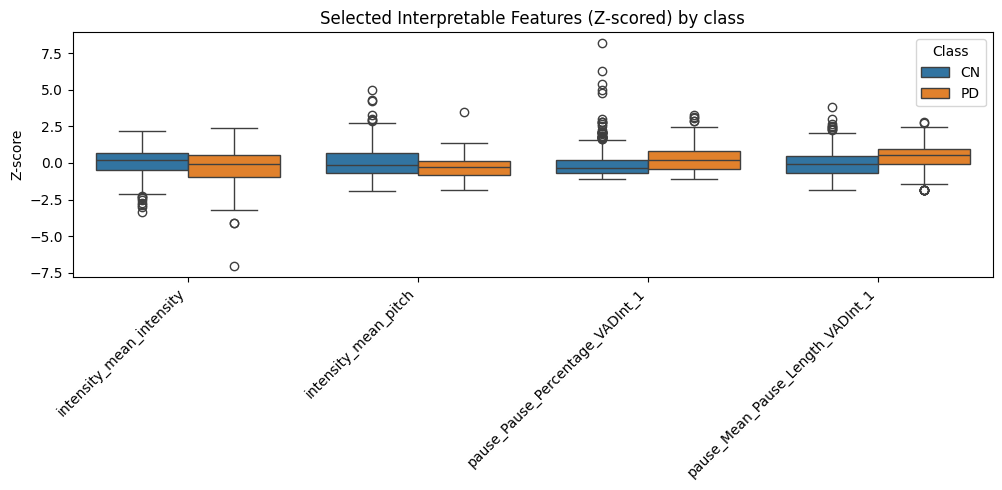

In [ ]:
#exploratory data analysis

#imports
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

#selecting a interpretable subset
interpretable_features_subset = ["intensity_mean_intensity", "intensity_mean_pitch",
                                 "pause_Pause_Percentage_VADInt_1", "pause_Mean_Pause_Length_VADInt_1"]

subset = usable[interpretable_features_subset + ["label"]].dropna()
subset["Label"] = subset["label"].map({0: "CN", 1: "PD"})

#standardize the features since they have different scales
subset_z = subset.copy()
for f in interpretable_features_subset:
  subset_z[f] = (subset_z[f] - subset_z[f].mean()) /subset_z[f].std(ddof=0)

long_df = subset_z.melt(id_vars="Label", value_vars=interpretable_features_subset, var_name="Feature", value_name="Z_value")

#boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(data=long_df, x="Feature", y="Z_value", hue="Label")
plt.xticks(rotation=45, ha="right")
plt.title("Selected Interpretable Features (Z-scored) by class")
plt.xlabel("")
plt.ylabel("Z-score")
plt.legend(title="Class")
plt.tight_layout()
plt.show()

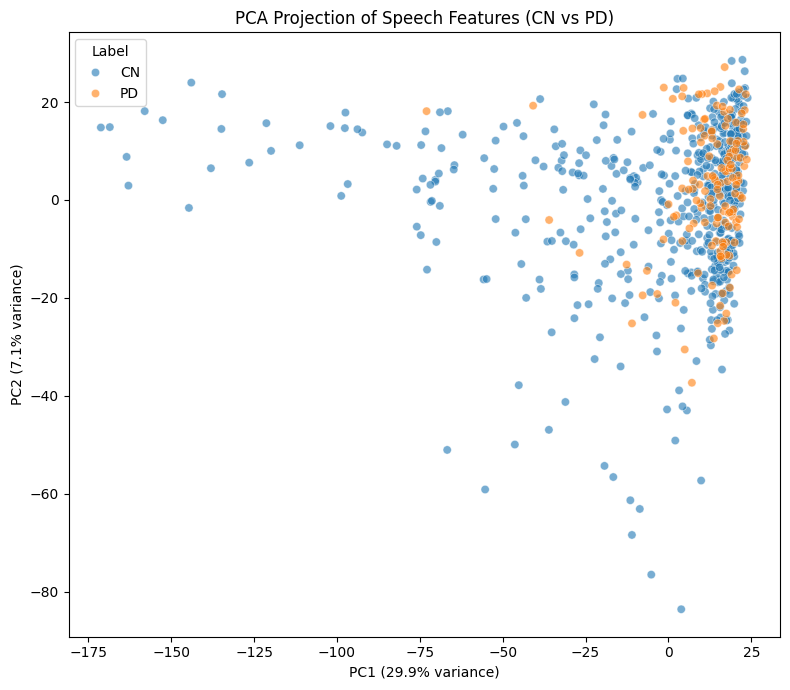

In [ ]:
#PCA visualization to compare PD and CN

#imports
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#creating class labels
X = usable.select_dtypes(include=[np.number]).drop(columns=["label"])
y = usable["label"]

X_filled = X.fillna(X.mean())
X_scaled = StandardScaler().fit_transform(X_filled)

#PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({"PC1": X_pca[:, 0],
                       "PC2": X_pca[:, 1],
                       "Label": y.map({0: "CN", 1: "PD"})})

#plot
plt.figure(figsize=(8, 7))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Label", alpha=0.6)
plt.title("PCA Projection of Speech Features (CN vs PD)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.tight_layout()
plt.show()


#Baseline Model Functions, Evaluation and Data Preparation Functions

In [ ]:
#data preperation

#imports
from sklearn.model_selection import GroupShuffleSplit
import numpy as np
import pandas as pd

def split_data(df, label_col="label", group_col="person_id", test_size=0.2,
               random_state=0, feature_cols=None, verbose=True):

  df = df.copy()

  #feature labels
  y = df[label_col].astype(int)

  if feature_cols is None:
     X = df.select_dtypes(include=[np.number]).drop(columns=[label_col], errors="ignore")
  else:
     feature_cols = [c for c in feature_cols if c in df.columns]
     X = df[feature_cols].copy()


  #to avoid leakage of the same person in both train and test
  groups = df["person_id"]

  #splitting the groups
  ggs = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
  train_indx, test_indx, = next(ggs.split(X, y, groups=groups))

  X_train, X_test = X.iloc[train_indx], X.iloc[test_indx]
  y_train, y_test = y.iloc[train_indx], y.iloc[test_indx]

  # printing distribution information
  if verbose:
    print("X shape:", X.shape)
    print("y distribution:\n", y.value_counts())
    print("Num unique persons:", groups.nunique())

    print("\nTrain shapes:", X_train.shape, y_train.shape)
    print("Test shapes:", X_test.shape, y_test.shape)
    print("\nTrain label distribution:\n", y_train.value_counts())
    print("Test label distribution:\n", y_test.value_counts())

  return X_train, X_test, y_train, y_test, train_indx, test_indx

In [ ]:
#metrics to evaluate each model

#imports
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, balanced_accuracy_score)

def evaluate_model(name, model, X_test, y_test, y_proba=None):
  y_pred = model.predict(X_test)

  #model evaluation metrics
  print(f"\n {name}")
  print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred))
  print("Confusion matric:\n", confusion_matrix(y_test, y_pred))
  print("\nClassification report:\n", classification_report(y_test, y_pred, digits=3))

  #ROC-AUC
  if y_proba is not None:
    auc = roc_auc_score(y_test, y_proba)
    print("ROC-AUC:", auc)


In [ ]:
#baseline model logistic regression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

def log_reg(C=1, max_iter=5000, class_weight="balanced", solver="saga", random_state=1):
  return Pipeline(steps=[
      ("imputer", SimpleImputer(strategy="median")),
      ("scaler", StandardScaler()),
      ("cfl", LogisticRegression(C=C, max_iter=max_iter, class_weight=class_weight,
                                solver=solver, n_jobs=-1, random_state=random_state))])


In [ ]:
#linear SVM
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

def linear_svm(random_state=1, max_iter=10000, cv=3, method="sigmoid"):
  svm = Pipeline(steps=[
      ("imputer", SimpleImputer(strategy="median")),
      ("scaler", StandardScaler()),
      ("clf", LinearSVC(class_weight="balanced", random_state=random_state))])

  svm_cal = CalibratedClassifierCV(svm, method=method, cv=cv)
  return svm_cal

In [ ]:
#Random forest
from sklearn.ensemble import RandomForestClassifier

def rand_forest(n_estimators=300, random_state=1, n_jobs=-1, class_weight="balanced"):
  rf = RandomForestClassifier(n_estimators=n_estimators, class_weight=class_weight,
                              random_state=random_state, n_jobs=n_jobs)
  return rf


In [ ]:
#Hyperparameter tuning for logistic regression

#imports
from sklearn.model_selection import GridSearchCV, GroupKFold

#splitting the data
X_train, X_test, y_train, y_test, train_indx, test_indx = split_data(usable)
groups_train = usable.iloc[train_indx]["person_id"]

#logistic regression pipeline
logreg_pipeline = Pipeline(steps=[("imputer", SimpleImputer(strategy="median")),
                                  ("scaler", StandardScaler()),
                                  ("cfl", LogisticRegression(max_iter=5000, class_weight="balanced",
                                                               solver="saga", n_jobs=-1))])

#regularization strength values to evaluate
param_grid = {"cfl__C": [0.01, 0.1, 1, 10]}
cv = GroupKFold(n_splits=5) #group split

#grid search with balanced accuracy
grid = GridSearchCV(estimator=logreg_pipeline, param_grid=param_grid,
                    scoring="balanced_accuracy", cv=cv, n_jobs=-1)

#fitting the model
grid.fit(X_train, y_train, groups=groups_train)

#printing the results
print("Best parameters:", grid.best_params_)
print("Best CV balanced accuracy:", grid.best_score_)

X shape: (700, 3516)
y distribution:
 label
0    555
1    145
Name: count, dtype: int64
Num unique persons: 24

Train shapes: (590, 3516) (590,)
Test shapes: (110, 3516) (110,)

Train label distribution:
 label
0    473
1    117
Name: count, dtype: int64
Test label distribution:
 label
0    82
1    28
Name: count, dtype: int64
Best parameters: {'cfl__C': 0.01}
Best CV balanced accuracy: 0.6475926905086269


#Exploring Several Classification models

In [ ]:
#comparing all three models

#imports
import pandas as pd
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, classification_report

X_train, X_test, y_train, y_test, train_indx, test_indx = split_data(usable)

#test set metadata table
test_meta = usable.iloc[test_indx][["uid", "person_id", "video_id",
                                    "years_from_diagnosis",
                                    "before_after_diagnosis"]].reset_index(drop=True)

#helper function to help build report table rows
def evaluate_to_row(name, model, X_test, y_test, y_proba=None):
  y_pred = model.predict(X_test)
  bal_acc = balanced_accuracy_score(y_test, y_pred)

  #classification report as a dictionary
  report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
  pd_precision = report["1"]["precision"] if "1" in report else float("nan")
  pd_recall = report["1"]["recall"] if "1" in report else float("nan")
  pd_f1 = report["1"]["f1-score"] if "1" in report else float(nan)

  auc = roc_auc_score(y_test, y_proba) if y_proba is not None else float("nan")

  return {"Model": name, "Balanced Acc": bal_acc, "ROC_AUC": auc,
          "PD Precision": pd_precision, "PD Recall": pd_recall}

#helper function to display the metadata information associated with each test PD
#also includes whether the sample was guessed correctly or not
def pd_outcomes_table(model_name, y_true, y_pred, y_proba, meta_df):
  out = meta_df.copy()
  out["y_true"] = y_true.reset_index(drop=True)
  out["y_pred"] = pd.Series(y_pred).reset_index(drop=True)
  out["p_PD"] = pd.Series(y_proba).reset_index(drop=True) if y_proba is not None else pd.NA
  out = out[out["y_true"] == 1].copy()
  out["correct"] = out["y_pred"] == 1
  out["Model"] = model_name
  out = out.sort_values(["correct", "p_PD"], ascending=[True, True])
  return out

results = []
pd_tables = []

#logistic regression
logreg = log_reg()
logreg.fit(X_train, y_train)
y_proba_lr = logreg.predict_proba(X_test)[:, 1]
y_pred_lr = logreg.predict(X_test)
evaluate_model("Logistic Regression", logreg, X_test, y_test, y_proba=y_proba_lr)
results.append(evaluate_to_row("Logistic Regression", logreg, X_test, y_test, y_proba_lr))
pd_tables.append(pd_outcomes_table("Logistic Regression", y_test, y_pred_lr, y_proba_lr, test_meta))

#linear SVM
svm_cal = linear_svm()
svm_cal.fit(X_train, y_train)
y_proba_svm = svm_cal.predict_proba(X_test)[:, 1]
y_pred_svm = svm_cal.predict(X_test)
evaluate_model("Linear SVM", svm_cal, X_test, y_test, y_proba=y_proba_svm)
results.append(evaluate_to_row("Linear SVM", svm_cal, X_test, y_test, y_proba_svm))
pd_tables.append(pd_outcomes_table("Linear SVM", y_test, y_pred_svm, y_proba_svm, test_meta))

#Random forest
rf = rand_forest()
rf.fit(X_train, y_train)
y_proba_rf = rf.predict_proba(X_test)[:,1]
y_pred_rf = rf.predict(X_test)
evaluate_model("Random forest", rf, X_test, y_test, y_proba=y_proba_rf)
results.append(evaluate_to_row("Random Forest", rf, X_test, y_test, y_proba=y_proba_rf))
pd_tables.append(pd_outcomes_table("Random Forest", y_test, y_pred_rf, y_proba_rf, test_meta))

#displaying the metric results
results_df = pd.DataFrame(results).sort_values(by="Balanced Acc",ascending=False)
display(results_df)

#pd cases table
pd_cases_df = pd.concat(pd_tables, ignore_index=True)
pd.set_option("display.max_rows", None)
display(pd_cases_df)

X shape: (700, 3516)
y distribution:
 label
0    555
1    145
Name: count, dtype: int64
Num unique persons: 24

Train shapes: (590, 3516) (590,)
Test shapes: (110, 3516) (110,)

Train label distribution:
 label
0    473
1    117
Name: count, dtype: int64
Test label distribution:
 label
0    82
1    28
Name: count, dtype: int64

 Logistic Regression
Balanced accuracy: 0.8610627177700348
Confusion matric:
 [[68 14]
 [ 3 25]]

Classification report:
               precision    recall  f1-score   support

           0      0.958     0.829     0.889        82
           1      0.641     0.893     0.746        28

    accuracy                          0.845       110
   macro avg      0.799     0.861     0.818       110
weighted avg      0.877     0.845     0.853       110

ROC-AUC: 0.953397212543554

 Linear SVM
Balanced accuracy: 0.7735191637630662
Confusion matric:
 [[80  2]
 [12 16]]

Classification report:
               precision    recall  f1-score   support

           0      0.870  

,Model,Balanced Acc,ROC_AUC,PD Precision,PD Recall
0,Logistic Regression,0.861063,0.953397,0.641026,0.892857
1,Linear SVM,0.773519,0.940331,0.888889,0.571429
2,Random Forest,0.607143,0.920078,1.000000,0.214286


,uid,person_id,video_id,years_from_diagnosis,before_after_diagnosis,y_true,y_pred,p_PD,correct,Model
0,pd_15_06p72ldrjgq_speaker_03,pd_15,06p72ldrjgq,16.0,after,1,0,0.041950,False,Logistic Regression
1,pd_21_nsgg1jt92z8_speaker_00,pd_21,nsgg1jt92z8,14.0,after,1,0,0.102087,False,Logistic Regression
2,pd_15_ewmaicl6yri_speaker_03,pd_15,ewmaicl6yri,19.0,after,1,0,0.375468,False,Logistic Regression
3,pd_15_lea7yos7coc_speaker_00,pd_15,lea7yos7coc,10.0,after,1,1,0.595777,True,Logistic Regression
4,pd_15_g8imwkl9cxg_speaker_00,pd_15,g8imwkl9cxg,10,after,1,1,0.602330,True,Logistic Regression
5,pd_15_38dweyi6bmc_speaker_02,pd_15,38dweyi6bmc,14.0,after,1,1,0.853388,True,Logistic Regression
6,pd_15_xqeg-6pqyh8_speaker_01,pd_15,xqeg-6pqyh8,10.0,after,1,1,0.883282,True,Logistic Regression
7,pd_21_a25tlegqnu4_speaker_02,pd_21,a25tlegqnu4,10.0,after,1,1,0.956448,True,Logistic Regression
8,pd_23_tljafkzmnrk_speaker_01,pd_23,tljafkzmnrk,2.0,before,1,1,0.957548,True,Logistic Regression
9,pd_23_wsbthlce95u_speaker_05,pd_23,wsbthlce95u,8.0,after,1,1,0.965466,True,Logistic Regression


#Feature Comparison

In [ ]:
#feature comparison

#imports
import pandas as pd
import numpy as np

#defining the feature groups
feature_sets = {"All features": None, "Interpretable only": [
    c for c in usable.columns if c.startswith("intensity_") or c.startswith("pause_")],
                "Non-Interpretable only": [c for c in usable.columns
                                           if any(c.startswith(p) for p in ["xvector_", "wav2vec_",
                                                                            "hubert_", "whisper_", "trillsson"])]}

#splitting the data
X_train, X_test, y_train, y_test, train_indx, test_indx = split_data(usable)
results = []

#looping over the features
for feat_name, feat_cols in feature_sets.items():

  X_train, X_test, y_train, y_test, _, _,= split_data(usable, feature_cols=feat_cols)

  print(f"\nFeature set: {feat_name}")
  print("Number of features:", X_train.shape[1])

  #logistic regression
  logreg = log_reg()
  logreg.fit(X_train, y_train)
  y_proba_lr = logreg.predict_proba(X_test)[:, 1]
  results.append(evaluate_to_row(f"Logreg ({feat_name})", logreg, X_test, y_test, y_proba_lr))

  #linear SVM
  svm_cal = linear_svm()
  svm_cal.fit(X_train, y_train)
  y_proba_svm = svm_cal.predict_proba(X_test)[:, 1]
  results.append(evaluate_to_row(f"SVM ({feat_name})", svm_cal, X_test, y_test, y_proba_svm))

  #Random forest
  rf = rand_forest()
  rf.fit(X_train, y_train)
  y_proba_rf = rf.predict_proba(X_test)[:, 1]
  results.append(evaluate_to_row(f"RF ({feat_name})", rf, X_test, y_test, y_proba_rf))

#displaying the results
feature_results_df = (pd.DataFrame(results).sort_values(by="Balanced Acc", ascending=False).reset_index(drop=True))
display(feature_results_df)


X shape: (700, 3516)
y distribution:
 label
0    555
1    145
Name: count, dtype: int64
Num unique persons: 24

Train shapes: (590, 3516) (590,)
Test shapes: (110, 3516) (110,)

Train label distribution:
 label
0    473
1    117
Name: count, dtype: int64
Test label distribution:
 label
0    82
1    28
Name: count, dtype: int64
X shape: (700, 3516)
y distribution:
 label
0    555
1    145
Name: count, dtype: int64
Num unique persons: 24

Train shapes: (590, 3516) (590,)
Test shapes: (110, 3516) (110,)

Train label distribution:
 label
0    473
1    117
Name: count, dtype: int64
Test label distribution:
 label
0    82
1    28
Name: count, dtype: int64

Feature set: All features
Number of features: 3516
X shape: (700, 60)
y distribution:
 label
0    555
1    145
Name: count, dtype: int64
Num unique persons: 24

Train shapes: (590, 60) (590,)
Test shapes: (110, 60) (110,)

Train label distribution:
 label
0    473
1    117
Name: count, dtype: int64
Test label distribution:
 label
0    82
1

,Model,Balanced Acc,ROC_AUC,PD Precision,PD Recall
0,Logreg (All features),0.861063,0.953397,0.641026,0.892857
1,Logreg (Non-Interpretable only),0.855401,0.950348,0.666667,0.857143
2,SVM (All features),0.773519,0.940331,0.888889,0.571429
3,SVM (Non-Interpretable only),0.737805,0.938153,0.875000,0.500000
4,RF (Interpretable only),0.660714,0.857796,1.000000,0.321429
5,Logreg (Interpretable only),0.633275,0.731707,0.390244,0.571429
6,RF (All features),0.607143,0.920078,1.000000,0.214286
7,RF (Non-Interpretable only),0.589286,0.912239,1.000000,0.178571
8,SVM (Interpretable only),0.535714,0.759582,1.000000,0.071429


In [ ]:
#repeated group splits summary (might not include)
import numpy as np
import pandas as pd

interpretable_columns = [c for c in usable.columns if c.startswith("intensity_") or c.startswith("pause_")]

n_runs = 30
rows = []

for rs in range(1, n_runs + 1):
  X_train, X_test, y_train, y_test, train_indx, test_indx = split_data(usable, feature_cols=interpretable_columns, verbose=False, random_state=rs)

  if y_test.nunique() < 2:
    continue

  #log regression
  lr = log_reg()
  lr.fit(X_train, y_train)
  y_proba_lr = lr.predict_proba(X_test)[:, 1]
  rows.append({**evaluate_to_row("Logreg (Interpretable)", lr, X_test, y_test, y_proba_lr), "run": rs})

  #linear svm
  svm_cal = linear_svm()
  svm_cal.fit(X_train, y_train)
  y_proba_svm = svm_cal.predict_proba(X_test)[:, 1]
  rows.append({**evaluate_to_row("SVM (Interpretable)", svm_cal, X_test, y_test, y_proba_svm), "run": rs})

  #random forest
  rf = rand_forest()
  rf.fit(X_train, y_train)
  y_proba_rf = rf.predict_proba(X_test)[:, 1]
  rows.append({**evaluate_to_row("Random Forest (Interpretable)", rf, X_test, y_test, y_proba_rf), "run": rs})

  runs_df = pd.DataFrame(rows)

  #summary
  summary = (runs_df.groupby("Model")[["Balanced Acc", "ROC_AUC", "PD Precision", "PD Recall"]]
             .agg(["mean", "std"]).sort_values(("Balanced Acc", "mean"), ascending=False))

#displaying the summary
display(summary)


X shape: (700, 60)
y distribution:
 label
0    555
1    145
Name: count, dtype: int64
Num unique persons: 24

Train shapes: (629, 60) (629,)
Test shapes: (71, 60) (71,)

Train label distribution:
 label
0    535
1     94
Name: count, dtype: int64
Test label distribution:
 label
1    51
0    20
Name: count, dtype: int64
X shape: (700, 60)
y distribution:
 label
0    555
1    145
Name: count, dtype: int64
Num unique persons: 24

Train shapes: (525, 60) (525,)
Test shapes: (175, 60) (175,)

Train label distribution:
 label
0    409
1    116
Name: count, dtype: int64
Test label distribution:
 label
0    146
1     29
Name: count, dtype: int64
X shape: (700, 60)
y distribution:
 label
0    555
1    145
Name: count, dtype: int64
Num unique persons: 24

Train shapes: (646, 60) (646,)
Test shapes: (54, 60) (54,)

Train label distribution:
 label
0    555
1     91
Name: count, dtype: int64
Test label distribution:
 label
1    54
Name: count, dtype: int64
X shape: (700, 60)
y distribution:
 label

Balanced Acc             ROC_AUC            \
                                      mean       std      mean       std   
Model                                                                      
Logreg (Interpretable)            0.627073  0.101407  0.699189  0.109204   
Random Forest (Interpretable)     0.547758  0.046038  0.754849  0.069994   
SVM (Interpretable)               0.518450  0.044916  0.698982  0.101843   

                              PD Precision           PD Recall            
                                      mean       std      mean       std  
Model                                                                     
Logreg (Interpretable)            0.373560  0.245807  0.520054  0.177541  
Random Forest (Interpretable)     0.488186  0.316500  0.131005  0.089728  
SVM (Interpretable)               0.229783  0.371165  0.043646  0.097949

In [ ]:
#Interpretable feature importance

#imports
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance

#selecting the interpretable feature columns
interpretable_columns = [c for c in usable.columns if c.startswith("intensity_") or c.startswith("pause_")]
X_train, X_test, y_train, y_test, train_indx, test_indx = split_data(usable, feature_cols=interpretable_columns)

#using logistic regression as the model
lr = log_reg()
lr.fit(X_train, y_train)

#permutation importance
perm = permutation_importance(lr, X_test, y_test, scoring="balanced_accuracy",
                              n_repeats=10, random_state=1, n_jobs=-1)

#creating the dataframe
importance_df = pd.DataFrame({"feature": X_test.columns, "importance_mean": perm["importances_mean"],
                              "importance_std": perm["importances_std"]}).sort_values("importance_mean", ascending=False)

#displaying the results
display(importance_df.head(25))


X shape: (700, 60)
y distribution:
 label
0    555
1    145
Name: count, dtype: int64
Num unique persons: 24

Train shapes: (590, 60) (590,)
Test shapes: (110, 60) (110,)

Train label distribution:
 label
0    473
1    117
Name: count, dtype: int64
Test label distribution:
 label
0    82
1    28
Name: count, dtype: int64


,feature,importance_mean,importance_std
58,pause_Mean_Pause_Length_VADInt_3,0.074216,0.041712
15,intensity_stddev_pitch,0.059233,0.047906
45,pause_Pause_Variability_VADInt_1,0.045122,0.029435
35,intensity_fitch_vtl,0.042030,0.031430
7,intensity_median_intensity,0.035976,0.022807
43,pause_Pause_Speech_Ratio_VADInt_1,0.025174,0.027305
24,intensity_f3_mean,0.020819,0.019601
42,pause_Pause_Percentage_VADInt_1,0.018641,0.022524
30,intensity_f3_median,0.015113,0.034659
38,pause_Unnamed: 0,0.011629,0.012563


#Training with a Max Number of Years of PD Data Before Diagnosis

In [ ]:
#filtering PD targets by max years before diagnosis

#imports
import numpy as np

#threshold for PD samples recorded before diagnosis
max_years_before = 5
df = usable.copy()

df["before_after_diagnosis_clean"] = df["before_after_diagnosis"].astype("string").str.strip().str.lower()

#identifying control and PD samples
is_control = df["label"] == 0
is_pd = df["label"] == 1

#identifying samples recorded before diagnosis
is_before = df["before_after_diagnosis_clean"] == "before"
years = pd.to_numeric(df["years_from_diagnosis"], errors = "coerce")

#keeping PD samples after the diagnosis threshold
keep_pd = (~is_before) | (years <= max_years_before)
filtered = df[is_control | (is_pd & keep_pd)].copy()

#data summary
print("Filtered dataset shape:", filtered.shape)
print("Label counts:\n", filtered["label"].value_counts())
print("PD before/after counts:\n", filtered.loc[filtered["label"]==1, "before_after_diagnosis_clean"].value_counts(dropna=False))

#train test split
X_train, X_test, y_train, y_test, train_indx, test_indx = split_data(filtered)

#training the logistic regession
logreg = log_reg()
logreg.fit(X_train, y_train)
y_proba_lr = logreg.predict_proba(X_test)[:, 1]
y_pred = logreg.predict(X_test)

#model evaluation printout
evaluate_model(f"Logistic Regression (PD >= {max_years_before} before)", logreg, X_test, y_test, y_proba=y_proba_lr)

#metrics for the results table
balanced_acc = balanced_accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba_lr)
report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
pd_precision = report["1"]["precision"]
pd_recall = report["1"]["recall"]

#results table
results_df = pd.DataFrame([{"Model": f"Logistic Regression (Max years before diagnosis threshold = {max_years_before})",
                            "Balanced ACC": balanced_acc, "ROC_AUC": roc_auc, "PD Precision": pd_precision,
                            "PD Recall": pd_recall}])

display(results_df)


Filtered dataset shape: (667, 3527)
Label counts:
 label
0.0    555
1.0    112
Name: count, dtype: int64
PD before/after counts:
 before_after_diagnosis_clean
after     87
before    21
same       4
Name: count, dtype: Int64
X shape: (667, 3516)
y distribution:
 label
0    555
1    112
Name: count, dtype: int64
Num unique persons: 24

Train shapes: (559, 3516) (559,)
Test shapes: (108, 3516) (108,)

Train label distribution:
 label
0    473
1     86
Name: count, dtype: int64
Test label distribution:
 label
0    82
1    26
Name: count, dtype: int64

 Logistic Regression (PD >= 5 before)
Balanced accuracy: 0.8803939962476548
Confusion matric:
 [[75  7]
 [ 4 22]]

Classification report:
               precision    recall  f1-score   support

           0      0.949     0.915     0.932        82
           1      0.759     0.846     0.800        26

    accuracy                          0.898       108
   macro avg      0.854     0.880     0.866       108
weighted avg      0.903     0.898  

,Model,Balanced ACC,ROC_AUC,PD Precision,PD Recall
0,Logistic Regression (Max years before diagnosi...,0.880394,0.945591,0.758621,0.846154
